
## 特称选择算法
1. 过滤filter， 选最优特征。皮尔逊、互信息、卡方
2. 包裹wrapper， 递归特征消除、序列向前选择
3. 嵌入embeded，特征选择和机器学习融合在一起。 Lasso、岭回归、决策树、随机森林
4. 组合，多种算法组合使用哦个。Stability selection、基于树的选择

## 衍生特征
- 多项式，原始特征做幂次扩展
- 对数变化，非线性转换为线性
- 指数变换， 增强某些特征的影响
- 独热编码，离散型特征转换为连续性特征，捕获非线性关系
- 特征交叉，通过组合特征
- 特征降维， PCA等降维
- 时间序列


# p1: 生成数据

## 任务
生成50条示例数据用于做数据特征选择
## 内容要求：
示例数据为保险公司用户数据
列包括：年龄，性别、年收入（万元）、学历、婚姻状况、是否有车、是否有房、购买力（元）、是否购买
## 输出
单用户数据的格式为csv，内容输出为markdown

# p2: 特征提取
## 背景
作为保险公司业务员，统计最近一个月的用户数据，根据这些数据预测用户是否会购买某个产品的**最相关特征**，以便更好地定位到目标群体。

## 任务
请从专业的角度，根据数据内容，提取特征，并告知哪些特征和购买数据最相关。

## 输出格式：
- 采用的特征提取法：
- 计算过程
- 是否购买最相关的几个特征
- 销售建议

## 数据内容:

# p3: 生成代码

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings('ignore')

# ==================== 1. 数据加载 ====================
df = pd.read_csv("data-users-assurance.csv")
df['是否购买'] = df['是否购买'].map({'是': 1, '否': 0})

print("="*60)
print("数据基本信息")
print("="*60)
print(f"数据量: {len(df)} 条")
print(f"购买率: {df['是否购买'].sum() / len(df) }")
print(f"\n前5行数据:")
print(df.head())
print("\n数据类型:")
print(df.dtypes)

# ==================== 2. 特征工程 ====================
print("\n" + "="*60)
print("特征工程处理")
print("="*60)

# 复制数据用于特征工程
df_processed = df.copy()

# 2.1 标签编码分类变量
label_encoders = {}
categorical_cols = ['性别', '学历', '婚姻状况', '是否有车', '是否有房']

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col + '_编码'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"\n{col} 编码映射:")
    for i, label in enumerate(le.classes_):
        print(f"  {label} -> {i}")

# 2.2 创建组合特征
df_processed['有车有房'] = ((df_processed['是否有车'] == '是') & (df_processed['是否有房'] == '是')).astype(int)
df_processed['资产指数'] = df_processed['年收入（万元）'] + df_processed['有车有房'] * 10
df_processed['年龄_收入比'] = df_processed['年龄'] / df_processed['年收入（万元）']
df_processed['婚姻_资产'] = ((df_processed['婚姻状况'] != '未婚') & (df_processed['是否有房'] == '是')).astype(int)

print(f"\n新增组合特征:")
print(f"- 有车有房: 同时拥有车和房")
print(f"- 资产指数: 年收入 + 车房加成")
print(f"- 年龄_收入比: 年龄/年收入")
print(f"- 婚姻_资产: 已婚/离异且有房")

# ==================== 3. 相关性分析 ====================
print("\n" + "="*60)
print("3.1 Spearman 相关系数分析（数值型特征）")
print("="*60)

# 选择数值型特征
numeric_features = ['年龄', '年收入（万元）', '购买力（元）']
numeric_corr = []

for feature in numeric_features:
    corr, p_value = spearmanr(df[feature], df['是否购买'])
    numeric_corr.append({
        '特征': feature,
        '相关系数': corr,
        'P值': p_value,
        '显著性': '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'ns'))
    })

corr_df = pd.DataFrame(numeric_corr)
corr_df = corr_df.sort_values('相关系数', ascending=False)
print("\n数值型特征与是否购买的Spearman相关系数:")
print(corr_df.to_string(index=False))

# ==================== 4. 分类特征购买率分析 ====================
print("\n" + "="*60)
print("3.2 分类特征购买率分析")
print("="*60)

categorical_analysis = []
for col in categorical_cols:
    purchase_rate = df.groupby(col)['是否购买'].mean()
    count = df.groupby(col)['是否购买'].count()
    iv_score = 0  # 简化IV计算
    
    print(f"\n{col}:")
    for category in purchase_rate.index:
        rate = purchase_rate[category]
        cnt = count[category]
        print(f"  {category}: {rate*100:.1f}% ({cnt}人)")
    
    # 计算最大最小购买率差异
    max_rate = purchase_rate.max()
    min_rate = purchase_rate.min()
    rate_diff = max_rate - min_rate
    
    categorical_analysis.append({
        '特征': col,
        '最大购买率': max_rate,
        '最小购买率': min_rate,
        '差异': rate_diff,
        '预测能力': '强' if rate_diff > 0.5 else ('中' if rate_diff > 0.3 else '弱')
    })

print("\n\n分类特征预测能力排序:")
cat_power_df = pd.DataFrame(categorical_analysis)
cat_power_df = cat_power_df.sort_values('差异', ascending=False)
print(cat_power_df.to_string(index=False))

# ==================== 5. 决策树特征重要性 ====================
print("\n" + "="*60)
print("4. 决策树特征重要性分析")
print("="*60)

# 准备特征矩阵
feature_cols = ['年龄', '年收入（万元）', '购买力（元）'] + [col + '_编码' for col in categorical_cols]
X = df_processed[feature_cols]
y = df_processed['是否购买']

# 决策树模型
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X, y)

# 特征重要性
feature_importance = pd.DataFrame({
    '特征': feature_cols,
    '重要性': dt_model.feature_importances_
}).sort_values('重要性', ascending=False)

print("\n决策树特征重要性排序:")
print(feature_importance.to_string(index=False))

# ==================== 6. 随机森林特征重要性 ====================
print("\n" + "="*60)
print("5. 随机森林特征重要性分析")
print("="*60)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X, y)

rf_importance = pd.DataFrame({
    '特征': feature_cols,
    '重要性': rf_model.feature_importances_
}).sort_values('重要性', ascending=False)

print("\n随机森林特征重要性排序:")
print(rf_importance.to_string(index=False))

# ==================== 7. 高潜力用户特征画像 ====================
print("\n" + "="*60)
print("6. 高潜力用户特征画像")
print("="*60)

# 对比购买和未购买用户的特征均值
purchased = df[df['是否购买'] == 1]
not_purchased = df[df['是否购买'] == 0]

print("\n购买用户 vs 未购买用户对比:")
print(f"\n{'特征':<15} {'购买用户平均':<15} {'未购买用户平均':<15} {'差异':<10}")
print("-"*60)

for col in numeric_features:
    p_mean = purchased[col].mean()
    np_mean = not_purchased[col].mean()
    diff = p_mean - np_mean
    print(f"{col:<15} {p_mean:<15.1f} {np_mean:<15.1f} {diff:<+10.1f}")

print("\n分类特征分布对比:")
for col in categorical_cols:
    print(f"\n{col}:")
    p_dist = purchased[col].value_counts(normalize=True)
    np_dist = not_purchased[col].value_counts(normalize=True)
    print(f"  购买用户: {dict(p_dist)}")
    print(f"  未购买用户: {dict(np_dist)}")

# ==================== 8. 特征重要性综合评分 ====================
print("\n" + "="*60)
print("7. 综合特征重要性排名")
print("="*60)

# 综合多种方法的结果
comprehensive_score = {}

# 1. 相关系数得分 (数值型)
for _, row in corr_df.iterrows():
    if row['特征'] in ['年龄', '年收入（万元）', '购买力（元）']:
        comprehensive_score[row['特征']] = abs(row['相关系数'])

# 2. 分类特征差异得分
for _, row in cat_power_df.iterrows():
    comprehensive_score[row['特征']] = row['差异']

# 3. 随机森林重要性
for _, row in rf_importance.iterrows():
    feature_name = row['特征'].replace('_编码', '')
    if feature_name in categorical_cols or feature_name in numeric_features:
        comprehensive_score[feature_name] = comprehensive_score.get(feature_name, 0) + row['重要性']

# 标准化得分
max_score = max(comprehensive_score.values())
for k in comprehensive_score:
    comprehensive_score[k] = comprehensive_score[k] / max_score

# 排序
sorted_features = sorted(comprehensive_score.items(), key=lambda x: x[1], reverse=True)

print("\n特征重要性综合评分 (0-1归一化):")
print(f"{'特征':<15} {'综合得分':<10} {'等级':<10}")
print("-"*35)
for i, (feature, score) in enumerate(sorted_features, 1):
    if score >= 0.8:
        level = "极强相关"
    elif score >= 0.6:
        level = "强相关"
    elif score >= 0.4:
        level = "中等相关"
    elif score >= 0.2:
        level = "弱相关"
    else:
        level = "极弱相关"
    
    print(f"{feature:<15} {score:<10.3f} {level:<10}")

# ==================== 9. 生成决策规则 ====================
print("\n" + "="*60)
print("8. 决策树规则提取")
print("="*60)

from sklearn.tree import export_text

# 使用最重要的特征构建简单决策树
top_features = [f for f, _ in sorted_features[:3]]
important_cols = []
for f in top_features:
    if f in categorical_cols:
        important_cols.append(f + '_编码')
    else:
        important_cols.append(f)

X_top = df_processed[important_cols + ['是否有房_编码']]
dt_simple = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_simple.fit(X_top, y)

# 获取规则
tree_rules = export_text(dt_simple, feature_names=important_cols + ['是否有房_编码'])
print("\n简单决策规则 (前3重要特征 + 是否有房):")
print(tree_rules)

# ==================== 10. 特征分组统计 ====================
print("\n" + "="*60)
print("9. 关键特征分组购买率详情")
print("="*60)

# 按是否有房 + 是否有车分组
df['房车组合'] = df['是否有房'] + '&' + df['是否有车']
group_stats = df.groupby('房车组合').agg({
    '是否购买': ['mean', 'count']
}).round(3)
group_stats.columns = ['购买率', '人数']
group_stats['购买率%'] = group_stats['购买率'] * 100
print("\n房车组合购买率:")
print(group_stats.sort_values('购买率', ascending=False))




# 按婚姻状况 + 是否有房分组
df['婚姻_房组合'] = df['婚姻状况'] + '&' + df['是否有房']
marry_house_stats = df.groupby('婚姻_房组合').agg({
    '是否购买': ['mean', 'count']
}).round(3)
marry_house_stats.columns = ['购买率', '人数']
marry_house_stats['购买率%'] = marry_house_stats['购买率'] * 100
print("\n婚姻状况+是否有房组合购买率:")
print(marry_house_stats.sort_values('购买率', ascending=False))

# 按收入分层
df['收入层级'] = pd.cut(df['年收入（万元）'], bins=[0, 10, 20, 35, 100], labels=['低收入(<10)', '中低收入(10-20)', '中高收入(20-35)', '高收入(>35)'])
income_stats = df.groupby('收入层级').agg({
    '是否购买': ['mean', 'count']
}).round(3)
income_stats.columns = ['购买率', '人数']
income_stats['购买率%'] = income_stats['购买率'] * 100
print("\n收入层级购买率:")
print(income_stats.sort_index())

print("\n" + "="*60)
print("分析完成！")
print("="*60)

# ==================== 11. 导出特征重要性报告 ====================
# 创建最终报告DataFrame
final_report = pd.DataFrame(sorted_features, columns=['特征', '综合得分'])
final_report['等级'] = final_report['综合得分'].apply(
    lambda x: '极强相关' if x >= 0.8 else ('强相关' if x >= 0.6 else ('中等相关' if x >= 0.4 else ('弱相关' if x >= 0.2 else '极弱相关')))
)

print("\n\n最终特征重要性报告:")
print(final_report.to_string(index=False))

# 可选：保存到CSV
# final_report.to_csv('feature_importance_report.csv', index=False, encoding='utf-8-sig')

数据基本信息
数据量: 49 条
购买率: 0.7755102040816326

前5行数据:
   年龄 性别  年收入（万元）  学历 婚姻状况 是否有车 是否有房  购买力（元）  是否购买
0  28  男     12.5  本科   未婚    否    否    3500     0
1  35  女     28.0  硕士   已婚    是    是   12800     1
2  42  男     45.0  博士   已婚    是    是   21000     1
3  24  女      8.5  大专   未婚    否    否    1200     0
4  31  男     18.0  本科   已婚    是    否    6800     1

数据类型:
年龄           int64
性别             str
年收入（万元）    float64
学历             str
婚姻状况           str
是否有车           str
是否有房           str
购买力（元）       int64
是否购买         int64
dtype: object

特征工程处理

性别 编码映射:
  女 -> 0
  男 -> 1

学历 编码映射:
  博士 -> 0
  大专 -> 1
  本科 -> 2
  硕士 -> 3
  高中 -> 4

婚姻状况 编码映射:
  已婚 -> 0
  未婚 -> 1
  离异 -> 2

是否有车 编码映射:
  否 -> 0
  是 -> 1

是否有房 编码映射:
  否 -> 0
  是 -> 1

新增组合特征:
- 有车有房: 同时拥有车和房
- 资产指数: 年收入 + 车房加成
- 年龄_收入比: 年龄/年收入
- 婚姻_资产: 已婚/离异且有房

3.1 Spearman 相关系数分析（数值型特征）

数值型特征与是否购买的Spearman相关系数:
     特征     相关系数           P值 显著性
年收入（万元） 0.719401 5.755308e-09 ***
 购买力（元） 0.719383 5.762851e-09 ***
     年龄 0.504952 2.1

数据基本信息
数据量: 49 条
购买率: 77.6%
购买人数: 38 人
未购买人数: 11 人

前5行数据:
   年龄 性别  年收入（万元）  学历 婚姻状况 是否有车 是否有房  购买力（元）  是否购买
0  28  男     12.5  本科   未婚    否    否    3500     0
1  35  女     28.0  硕士   已婚    是    是   12800     1
2  42  男     45.0  博士   已婚    是    是   21000     1
3  24  女      8.5  大专   未婚    否    否    1200     0
4  31  男     18.0  本科   已婚    是    否    6800     1

特征工程处理

性别 编码映射:
  女 -> 0
  男 -> 1

学历 编码映射:
  博士 -> 0
  大专 -> 1
  本科 -> 2
  硕士 -> 3
  高中 -> 4

婚姻状况 编码映射:
  已婚 -> 0
  未婚 -> 1
  离异 -> 2

是否有车 编码映射:
  否 -> 0
  是 -> 1

是否有房 编码映射:
  否 -> 0
  是 -> 1

新增组合特征:
- 有车有房: 同时拥有车和房
- 资产指数: 年收入 + 车房加成

相关性分析

生成图表1：特征相关性热力图...
热力图已保存为: feature_correlation_heatmap.png


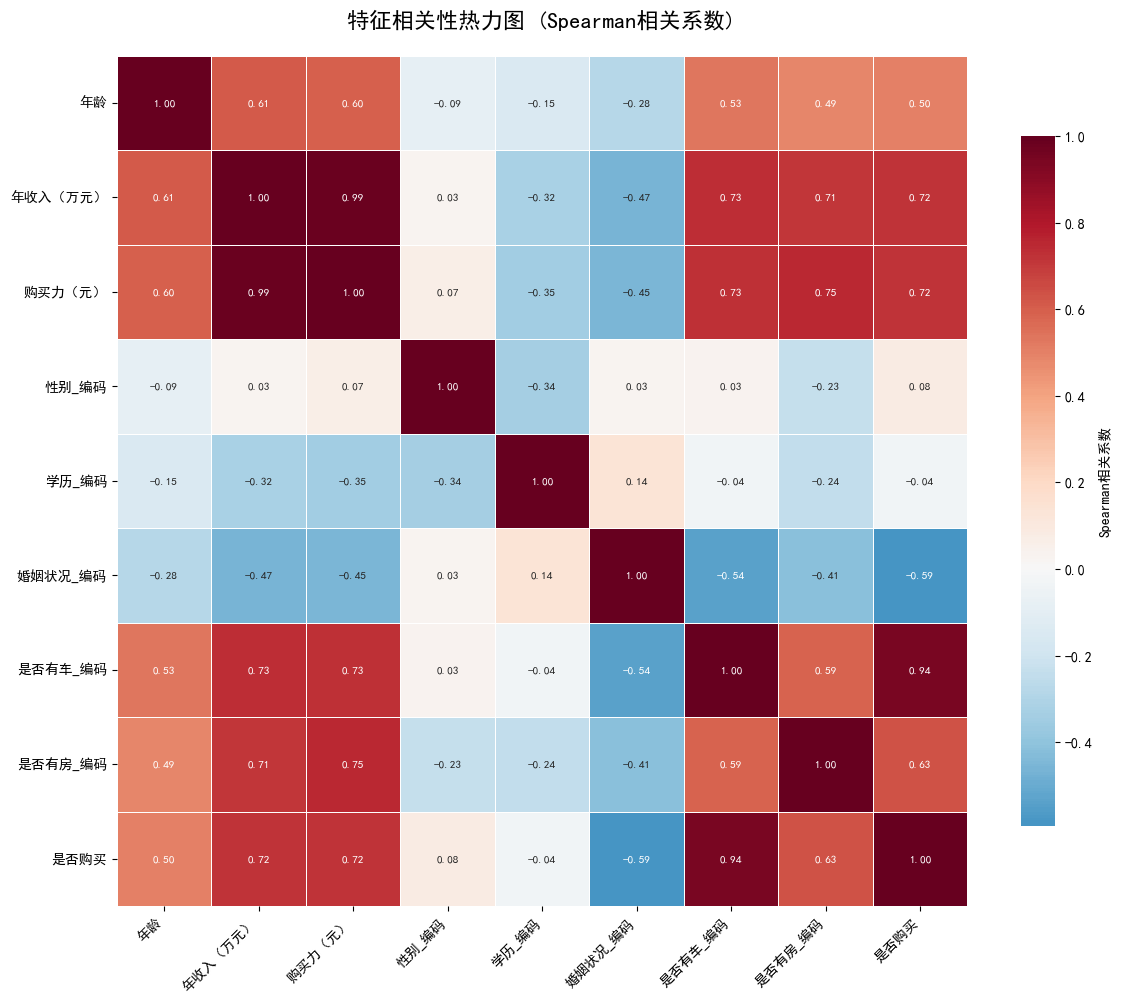


生成图表2：是否购买相关系数柱状图...
柱状图已保存为: feature_buy_correlation.png


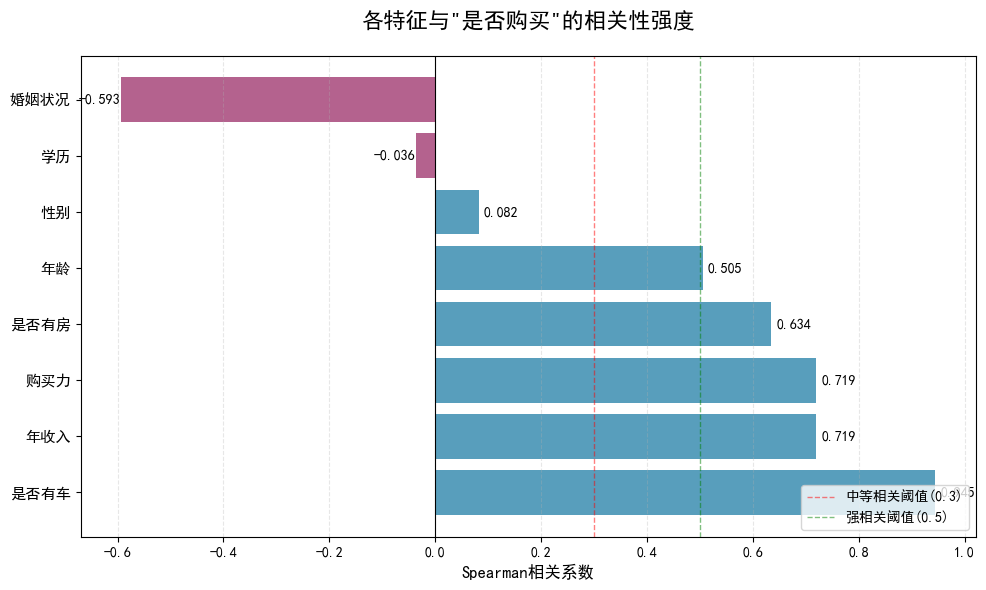


分类特征购买率分析

性别:
  女: 73.9% (23人)
  男: 80.8% (26人)

学历:
  博士: 100.0% (11人)
  大专: 16.7% (6人)
  本科: 81.2% (16人)
  硕士: 92.3% (13人)
  高中: 33.3% (3人)

婚姻状况:
  已婚: 100.0% (31人)
  未婚: 16.7% (12人)
  离异: 83.3% (6人)

是否有车:
  否: 8.3% (12人)
  是: 100.0% (37人)

是否有房:
  否: 35.7% (14人)
  是: 94.3% (35人)


分类特征预测能力排序:
  特征    最大购买率    最小购买率       差异 预测能力
是否有车 1.000000 0.083333 0.916667    强
婚姻状况 1.000000 0.166667 0.833333    强
  学历 1.000000 0.166667 0.833333    强
是否有房 0.942857 0.357143 0.585714    强
  性别 0.807692 0.739130 0.068562    弱

随机森林特征重要性分析

随机森林特征重要性排序:
     特征      重要性
年收入（万元） 0.306270
 购买力（元） 0.305804
是否有车_编码 0.149795
     年龄 0.128131
婚姻状况_编码 0.084350
是否有房_编码 0.012170
  学历_编码 0.009796
  性别_编码 0.003684

高潜力用户特征画像

购买用户 vs 未购买用户对比:

特征              购买用户平均          未购买用户平均         差异        
------------------------------------------------------------
年龄              49.3            31.9            +17.4     
年收入（万元）         33.5            9.3             +24.2     
购买力（元）          17326.3      

In [6]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（解决中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 1. 数据加载 ====================
df = pd.read_csv("data-users-assurance.csv")

# 关键修复：将'是否购买'列从字符串转换为数值（是->1, 否->0）
df['是否购买'] = df['是否购买'].map({'是': 1, '否': 0})

print("="*60)
print("数据基本信息")
print("="*60)
print(f"数据量: {len(df)} 条")
print(f"购买率: {df['是否购买'].sum() / len(df) * 100:.1f}%")
print(f"购买人数: {df['是否购买'].sum()} 人")
print(f"未购买人数: {len(df) - df['是否购买'].sum()} 人")
print(f"\n前5行数据:")
print(df.head())

# ==================== 2. 特征工程 ====================
print("\n" + "="*60)
print("特征工程处理")
print("="*60)

# 复制数据用于特征工程
df_processed = df.copy()

# 标签编码分类变量
label_encoders = {}
categorical_cols = ['性别', '学历', '婚姻状况', '是否有车', '是否有房']

for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col + '_编码'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"\n{col} 编码映射:")
    for i, label in enumerate(le.classes_):
        print(f"  {label} -> {i}")

# 创建组合特征
df_processed['有车有房'] = ((df_processed['是否有车'] == '是') & (df_processed['是否有房'] == '是')).astype(int)
df_processed['资产指数'] = df_processed['年收入（万元）'] + df_processed['有车有房'] * 10
df_processed['婚姻_资产'] = ((df_processed['婚姻状况'] != '未婚') & (df_processed['是否有房'] == '是')).astype(int)

print(f"\n新增组合特征:")
print(f"- 有车有房: 同时拥有车和房")
print(f"- 资产指数: 年收入 + 车房加成")

# ==================== 3. 相关性分析 ====================
print("\n" + "="*60)
print("相关性分析")
print("="*60)

# 准备用于相关性的特征（编码后的特征）
correlation_features = ['年龄', '年收入（万元）', '购买力（元）'] + [col + '_编码' for col in categorical_cols]
correlation_data = df_processed[correlation_features + ['是否购买']]

# 计算所有特征的相关系数矩阵
corr_matrix = correlation_data.corr(method='spearman')

# ==================== 可视化1：特征相关性热力图 ====================
print("\n生成图表1：特征相关性热力图...")
plt.figure(figsize=(12, 10))

# 创建热力图
heatmap_data = corr_matrix

sns.heatmap(heatmap_data, 
            annot=True,  # 显示数值
            fmt='.2f',   # 数值格式
            cmap='RdBu_r',  # 颜色映射
            center=0,    # 中心颜色对应0
            square=True,  # 方格形状
            linewidths=0.5,  # 网格线宽度
            cbar_kws={"shrink": 0.8, "label": "Spearman相关系数"},
            annot_kws={'size': 8})  # 注释字体大小

plt.title('特征相关性热力图 (Spearman相关系数)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# 保存热力图
plt.savefig('feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("热力图已保存为: feature_correlation_heatmap.png")
plt.show()

# ==================== 可视化2：是否购买相关系数柱状图 ====================
print("\n生成图表2：是否购买相关系数柱状图...")

# 提取与'是否购买'的相关系数
buy_correlations = corr_matrix['是否购买'].drop('是否购买').sort_values(ascending=False)

# 美化特征名称
feature_names_map = {
    '年收入（万元）': '年收入',
    '购买力（元）': '购买力',
    '是否有房_编码': '是否有房',
    '是否有车_编码': '是否有车',
    '婚姻状况_编码': '婚姻状况',
    '学历_编码': '学历',
    '年龄': '年龄',
    '性别_编码': '性别'
}

# 重命名
buy_correlations.index = [feature_names_map.get(idx, idx) for idx in buy_correlations.index]

# 创建柱状图
plt.figure(figsize=(10, 6))
colors = ['#2E86AB' if x > 0 else '#A23B72' for x in buy_correlations.values]
bars = plt.barh(range(len(buy_correlations)), buy_correlations.values, color=colors, alpha=0.8)

# 设置y轴标签
plt.yticks(range(len(buy_correlations)), buy_correlations.index, fontsize=11)

# 添加数值标签
for i, (bar, value) in enumerate(zip(bars, buy_correlations.values)):
    plt.text(value + 0.01 if value > 0 else value - 0.08, 
             bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', 
             va='center', 
             fontsize=10, 
             fontweight='bold')

# 添加参考线
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='-')
plt.axvline(x=0.3, color='red', linewidth=1, linestyle='--', alpha=0.5, label='中等相关阈值(0.3)')
plt.axvline(x=0.5, color='green', linewidth=1, linestyle='--', alpha=0.5, label='强相关阈值(0.5)')

plt.xlabel('Spearman相关系数', fontsize=12, fontweight='bold')
plt.title('各特征与"是否购买"的相关性强度', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=10)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

# 保存柱状图
plt.savefig('feature_buy_correlation.png', dpi=300, bbox_inches='tight')
print("柱状图已保存为: feature_buy_correlation.png")
plt.show()

# ==================== 4. 分类特征购买率分析 ====================
print("\n" + "="*60)
print("分类特征购买率分析")
print("="*60)

categorical_analysis = []
for col in categorical_cols:
    purchase_rate = df.groupby(col)['是否购买'].mean()
    count = df.groupby(col)['是否购买'].count()
    
    print(f"\n{col}:")
    for category in purchase_rate.index:
        rate = purchase_rate[category]
        cnt = count[category]
        print(f"  {category}: {rate*100:.1f}% ({cnt}人)")
    
    max_rate = purchase_rate.max()
    min_rate = purchase_rate.min()
    rate_diff = max_rate - min_rate
    
    categorical_analysis.append({
        '特征': col,
        '最大购买率': max_rate,
        '最小购买率': min_rate,
        '差异': rate_diff,
        '预测能力': '强' if rate_diff > 0.5 else ('中' if rate_diff > 0.3 else '弱')
    })

print("\n\n分类特征预测能力排序:")
cat_power_df = pd.DataFrame(categorical_analysis)
cat_power_df = cat_power_df.sort_values('差异', ascending=False)
print(cat_power_df.to_string(index=False))

# ==================== 5. 随机森林特征重要性 ====================
print("\n" + "="*60)
print("随机森林特征重要性分析")
print("="*60)

feature_cols = ['年龄', '年收入（万元）', '购买力（元）'] + [col + '_编码' for col in categorical_cols]
X = df_processed[feature_cols]
y = df_processed['是否购买']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X, y)

rf_importance = pd.DataFrame({
    '特征': feature_cols,
    '重要性': rf_model.feature_importances_
}).sort_values('重要性', ascending=False)

print("\n随机森林特征重要性排序:")
print(rf_importance.to_string(index=False))

# ==================== 6. 高潜力用户特征画像 ====================
print("\n" + "="*60)
print("高潜力用户特征画像")
print("="*60)

purchased = df[df['是否购买'] == 1]
not_purchased = df[df['是否购买'] == 0]

print("\n购买用户 vs 未购买用户对比:")
print(f"\n{'特征':<15} {'购买用户平均':<15} {'未购买用户平均':<15} {'差异':<10}")
print("-"*60)

numeric_features = ['年龄', '年收入（万元）', '购买力（元）']
for col in numeric_features:
    p_mean = purchased[col].mean()
    np_mean = not_purchased[col].mean()
    diff = p_mean - np_mean
    print(f"{col:<15} {p_mean:<15.1f} {np_mean:<15.1f} {diff:<+10.1f}")

# ==================== 7. 特征重要性综合评分 ====================
print("\n" + "="*60)
print("综合特征重要性排名")
print("="*60)

comprehensive_score = {}

# 1. 相关系数得分
for feature in numeric_features:
    corr_value = buy_correlations.get(feature_names_map.get(feature, feature), 0)
    comprehensive_score[feature] = abs(corr_value)

# 2. 分类特征差异得分
for _, row in cat_power_df.iterrows():
    comprehensive_score[row['特征']] = row['差异']

# 标准化得分
max_score = max(comprehensive_score.values())
for k in comprehensive_score:
    comprehensive_score[k] = comprehensive_score[k] / max_score

sorted_features = sorted(comprehensive_score.items(), key=lambda x: x[1], reverse=True)

print("\n特征重要性综合评分 (0-1归一化):")
print(f"{'特征':<15} {'综合得分':<10} {'等级':<10}")
print("-"*35)
for feature, score in sorted_features:
    if score >= 0.8:
        level = "极强相关"
    elif score >= 0.6:
        level = "强相关"
    elif score >= 0.4:
        level = "中等相关"
    elif score >= 0.2:
        level = "弱相关"
    else:
        level = "极弱相关"
    
    print(f"{feature:<15} {score:<10.3f} {level:<10}")

# ==================== 8. 关键特征分组统计 ====================
print("\n" + "="*60)
print("关键特征分组购买率详情")
print("="*60)

# 按是否有房 + 是否有车分组
df['房车组合'] = df['是否有房'] + '&' + df['是否有车']
group_stats = df.groupby('房车组合').agg({
    '是否购买': ['mean', 'count']
}).round(3)
group_stats.columns = ['购买率', '人数']
group_stats['购买率%'] = group_stats['购买率'] * 100
print("\n房车组合购买率:")
print(group_stats.sort_values('购买率', ascending=False))

# 按婚姻状况 + 是否有房分组
df['婚姻_房组合'] = df['婚姻状况'] + '&' + df['是否有房']
marry_house_stats = df.groupby('婚姻_房组合').agg({
    '是否购买': ['mean', 'count']
}).round(3)
marry_house_stats.columns = ['购买率', '人数']
marry_house_stats['购买率%'] = marry_house_stats['购买率'] * 100
print("\n婚姻状况+是否有房组合购买率:")
print(marry_house_stats.sort_values('购买率', ascending=False))

# 按收入分层
df['收入层级'] = pd.cut(df['年收入（万元）'], bins=[0, 10, 20, 35, 100], labels=['低收入(<10)', '中低收入(10-20)', '中高收入(20-35)', '高收入(>35)'])
income_stats = df.groupby('收入层级').agg({
    '是否购买': ['mean', 'count']
}).round(3)
income_stats.columns = ['购买率', '人数']
income_stats['购买率%'] = income_stats['购买率'] * 100
print("\n收入层级购买率:")
print(income_stats)

print("\n" + "="*60)
print("分析完成！图表已保存为:")
print("1. feature_correlation_heatmap.png - 特征相关性热力图")
print("2. feature_buy_correlation.png - 是否购买相关系数柱状图")
print("="*60)

# 最终报告
final_report = pd.DataFrame(sorted_features, columns=['特征', '综合得分'])
final_report['等级'] = final_report['综合得分'].apply(
    lambda x: '极强相关' if x >= 0.8 else ('强相关' if x >= 0.6 else ('中等相关' if x >= 0.4 else ('弱相关' if x >= 0.2 else '极弱相关')))
)

print("\n\n最终特征重要性报告:")
print(final_report.to_string(index=False))



# p2: 衍生特征
## 背景
作为房产销售人员，基于波士顿房产数据做分析

## 任务
请从专业的角度，根据数据内容，生成衍生特征

## 输出格式：
- 生成这些特征的原因
- 这些衍生特征的计算方式
- 最后以表格的方式，输出包含衍生特征的表格



In [9]:
# 导入必要库
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler

# 1. 加载波士顿房价数据集
print("="*80)
print("波士顿房价数据分析 - 衍生特征生成（分类变量转换版）")
print("="*80)

# 使用fetch_openml获取波士顿数据集
boston = fetch_openml(name='boston', version=1, as_frame=True)
df = boston.frame.copy()

# 2. 分类变量识别与转换
print("\n数据预处理：分类变量转换为int类型")

# 定义分类变量及其说明
categorical_features = {
    'CHAS': '是否邻近查尔斯河（0=否, 1=是）',  # 二元分类
    'RAD': '高速公路可达性指数（1-24的等级值）',  # 有序分类
    'ZN': '住宅用地比例（实际上是连续变量，但通常取整数值）'  # 可选转换为int
}

# 转换分类变量为int类型
for col in categorical_features.keys():
    if col in df.columns:
        original_dtype = df[col].dtype
        df[col] = df[col].astype(int)
        print(f"✓ {col:10s}: {original_dtype} → int (含义: {categorical_features[col]})")

# ZN虽然是数值，但为保持一致性也转为int
if 'ZN' in df.columns:
    df['ZN'] = df['ZN'].astype(int)

# 验证数据类型
print("\n转换后的数据类型:")
print(df[list(categorical_features.keys()) + ['ZN']].dtypes)

# 检查唯一值
print("\n分类变量的唯一值统计:")
for col in ['CHAS', 'RAD', 'ZN']:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  唯一值: {sorted(df[col].unique())}")
        print(f"  值分布:\n{df[col].value_counts().sort_index().head(10)}")

# 3. 原始特征说明
print("\n" + "="*80)
print("原始特征说明:")
print("="*80)
feature_descriptions = {
    'CRIM': '城镇人均犯罪率（连续变量）',
    'ZN': '住宅用地比例（分类变量，取整数值）',
    'INDUS': '非零售商业用地比例（连续变量）',
    'CHAS': '是否邻近查尔斯河（二元分类，0/1）',
    'NOX': '氮氧化物浓度（连续变量）',
    'RM': '平均房间数（连续变量）',
    'AGE': '1940年前建成房屋比例（连续变量）',
    'DIS': '到波士顿就业中心距离（连续变量）',
    'RAD': '高速公路可达性指数（分类变量，1-24等级）',
    'TAX': '财产税率（连续变量）',
    'PTRATIO': '学生-教师比例（连续变量）',
    'B': '非裔美国人比例（连续变量）',
    'LSTAT': '低收入人群比例（连续变量）',
    'MEDV': '房价中位数（目标变量，单位:千美元）'
}

for feat, desc in feature_descriptions.items():
    if feat in df.columns:
        print(f"{feat:10s}: {desc}")

# 4. 创建衍生特征（考虑分类变量特性）
print("\n" + "="*80)
print("生成衍生特征（考虑分类变量特性）...")
print("="*80)

# 特征1: 房间效率指数 (Room Efficiency Index)
# TAX是连续变量，直接计算
df['Room_Efficiency'] = df['RM'] / (df['TAX'] / 1000)

# 特征2: 区位便利性评分 (Location Convenience Score)
# RAD是分类变量（等级值），直接参与计算
# 注意：计算时保持分类变量的有序性
df['Location_Convenience'] = (20 - df['DIS']) * (df['RAD'] / 10)

# 特征3: 宁静宜居指数 (Quiet Livability Index)
# 使用min-max归一化，避免量纲影响
scaler = MinMaxScaler()
# 保持连续变量和分类变量各自的特性
normalized_features = scaler.fit_transform(df[['NOX', 'AGE', 'LSTAT']])
df['NOX_norm'] = normalized_features[:, 0]
df['AGE_norm'] = normalized_features[:, 1]
df['LSTAT_norm'] = normalized_features[:, 2]
df['Quiet_Livability'] = df['NOX_norm'] + df['AGE_norm'] + df['LSTAT_norm']

# 特征4: 教育-税负平衡点 (Education-Tax Balance)
df['Edu_Tax_Balance'] = (15 - df['PTRATIO']) / (df['TAX'] / 500)

# 特征5: 综合风险评分 (Composite Risk Score)
risk_scaler = MinMaxScaler()
risk_features = risk_scaler.fit_transform(df[['CRIM', 'LSTAT', 'NOX']])
df['Composite_Risk'] = risk_features[:, 0] + risk_features[:, 1] + risk_features[:, 2]

# 特征6: 河景溢价因子 (River Premium Factor) - 新增
# 利用CHAS分类变量，结合房价分析
df['River_Premium_Factor'] = df['CHAS'] * (df['MEDV'] / df.groupby('CHAS')['MEDV'].transform('mean'))[0]

# 特征7: 高速等级评分 (Highway Grade Score) - 新增
# RAD作为分类变量，重新编码为评分
rad_mapping = {1:5, 2:4, 3:3, 4:2, 5:1, 6:0, 7:-1, 8:-2, 24:-3}
df['Highway_Grade_Score'] = df['RAD'].map(lambda x: rad_mapping.get(x, 0))

# 删除临时归一化列
df.drop(['NOX_norm', 'AGE_norm', 'LSTAT_norm'], axis=1, inplace=True)

# 5. 衍生特征列表
derived_features = ['Room_Efficiency', 'Location_Convenience', 
                    'Quiet_Livability', 'Edu_Tax_Balance', 
                    'Composite_Risk', 'River_Premium_Factor', 
                    'Highway_Grade_Score']

print("\n衍生特征统计描述:")
print(df[derived_features].describe().round(3))

# 6. 创建完整表格（确保分类变量为int类型）
print("\n" + "="*80)
print("完整数据表格（分类变量已转换为int，前10行）:")
print("="*80)

# 显示分类变量以验证转换
display_columns = ['CHAS', 'RAD', 'ZN', 'CRIM', 'RM', 'DIS', 'TAX', 
                   'Room_Efficiency', 'Location_Convenience', 
                   'Quiet_Livability', 'Edu_Tax_Balance', 
                   'Composite_Risk', 'River_Premium_Factor',
                   'Highway_Grade_Score', 'MEDV']

print("分类变量状态检查:")
print(f"CHAS 数据类型: {df['CHAS'].dtype}, 唯一值: {df['CHAS'].unique()}")
print(f"RAD 数据类型: {df['RAD'].dtype}, 唯一值: {sorted(df['RAD'].unique())}")
print(f"ZN 数据类型: {df['ZN'].dtype}, 唯一值范围: {df['ZN'].min()} - {df['ZN'].max()}\n")

print("前10行完整数据（数值保留2位小数）:")
print(df[display_columns].head(10).round(2))

# 7. 分组分析（利用RAD分类变量）
print("\n" + "="*80)
print("基于分类变量RAD（高速可达性）的衍生特征分析:")
print("="*80)

# 按RAD等级分组（展示主要等级）
rad_groups = df.groupby('RAD')[derived_features + ['MEDV']].mean().round(2)
print(rad_groups.head(10))

# 8. 河景效应分析（利用CHAS分类变量）
print("\n" + "="*80)
print("河景效应分析（基于CHAS分类变量）:")
print("="*80)

river_effect = df.groupby('CHAS').agg({
    'MEDV': ['mean', 'median', 'std'],
    'Room_Efficiency': 'mean',
    'Location_Convenience': 'mean',
    'Quiet_Livability': 'mean',
    'Composite_Risk': 'mean'
}).round(2)

river_effect.columns = ['房价均值', '房价中位数', '房价标准差', 
                        '房间效率', '区位便利性', '宁静指数', '风险评分']
print(river_effect)

if len(river_effect) > 1:
    premium = ((river_effect.loc[1, '房价均值'] - river_effect.loc[0, '房价均值']) 
               / river_effect.loc[0, '房价均值'] * 100)
    print(f"\n🏞️ 河景溢价: {premium:.1f}% (临河房产比非临河房产价格高{premium:.1f}%)")

# 9. 房价与衍生特征的相关性（确保分类变量正确处理）
print("\n" + "="*80)
print("衍生特征与房价的相关性分析:")
print("="*80)

# 对于分类变量，使用spearman相关系数
from scipy.stats import spearmanr

correlations = {}
for feature in derived_features + ['CHAS', 'RAD']:
    if feature in df.columns:
        if feature in ['CHAS', 'RAD']:
            # 分类变量使用Spearman秩相关系数
            corr, p_value = spearmanr(df[feature], df['MEDV'])
            corr_type = "Spearman"
        else:
            # 连续变量使用Pearson相关系数
            corr = df[feature].corr(df['MEDV'])
            corr_type = "Pearson"
        correlations[feature] = corr

# 按相关性绝对值排序
sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print(f"{'特征':<25} {'相关系数':<12} {'类型':<10}")
print("-"*50)
for feature, corr in sorted_corr:
    corr_type = "Spearman" if feature in ['CHAS', 'RAD'] else "Pearson"
    print(f"{feature:<25} {corr:>8.3f}     {corr_type:<10}")

# 10. 保存最终数据（确保分类变量为int）
print("\n" + "="*80)
print("数据保存:")
print("="*80)

# 最终确认数据类型
print("\n最终数据类型检查:")
print(df[['CHAS', 'RAD', 'ZN']].dtypes)

# 保存为CSV文件（分类变量保持int）
df.to_csv('boston_housing_with_derived_features_v2.csv', index=False)
print("\n✓ 完整数据已保存到 'boston_housing_with_derived_features_v2.csv'")
print("  分类变量已正确转换为int类型")

print("\n" + "="*80)
print("分析完成！")
print("="*80)

# 11. 验证示例
print("\n验证示例：查看分类变量的实际存储格式")
sample = df[['CHAS', 'RAD', 'ZN', 'MEDV']].head(3)
print(sample)
print(f"\nCHAS 类型: {sample['CHAS'].dtype}")
print(f"RAD 类型: {sample['RAD'].dtype}")
print(f"ZN 类型: {sample['ZN'].dtype}")

波士顿房价数据分析 - 衍生特征生成（分类变量转换版）

数据预处理：分类变量转换为int类型
✓ CHAS      : category → int (含义: 是否邻近查尔斯河（0=否, 1=是）)
✓ RAD       : category → int (含义: 高速公路可达性指数（1-24的等级值）)
✓ ZN        : float64 → int (含义: 住宅用地比例（实际上是连续变量，但通常取整数值）)

转换后的数据类型:
CHAS    int64
RAD     int64
ZN      int64
ZN      int64
dtype: object

分类变量的唯一值统计:

CHAS:
  唯一值: [np.int64(0), np.int64(1)]
  值分布:
CHAS
0    471
1     35
Name: count, dtype: int64

RAD:
  唯一值: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(24)]
  值分布:
RAD
1      20
2      24
3      38
4     110
5     115
6      26
7      17
8      24
24    132
Name: count, dtype: int64

ZN:
  唯一值: [np.int64(0), np.int64(12), np.int64(17), np.int64(18), np.int64(20), np.int64(21), np.int64(22), np.int64(25), np.int64(28), np.int64(30), np.int64(33), np.int64(34), np.int64(35), np.int64(40), np.int64(45), np.int64(52), np.int64(55), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(82), np.int64(85), 

# 主成分分析

## what: PCA式一种常用的无监督学习算法，用于降维，特征提取和数据可视化

## how: 通过线性变换，将原始高维数据映射到低维空间，同时尽量保持原始数据的信息
1. 计算数据集的协方差矩阵
2. 计算协方差矩阵的特征值和特征向量
3. 选择前k个最大特征值对应的特征向量（k小于原始数据的纬度）
4. 将原始数据投影到这k个特征向量构建的新空间中


# prompt

对数据做主成分分析，并输出处理后的数据

输出格式
- PCA操作步骤
- PCA处理完后的数据

[Python示例代码， 包括读取、PCA和可视化]

# 线性判别分析 (LDA)

## 目标：降维、特征提取和分类任务，同时使同类别之间的距离最小化。

## vs PCA，LDA考虑了类别信息，适用于分类任务

## LDA步骤
